In [ ]:
# Step 1: Decision rule in logistic regression

# s(z) represents the probability that a sample belongs to class 1
# 1 - s(z) represents the probability that a sample belongs to class 0

# Decision rule:
# If s(z) > 0.5 → predict class 1
# If s(z) < 0.5 → predict class 0

# This threshold (0.5) is derived from comparing:
# s(z) and 1 - s(z)

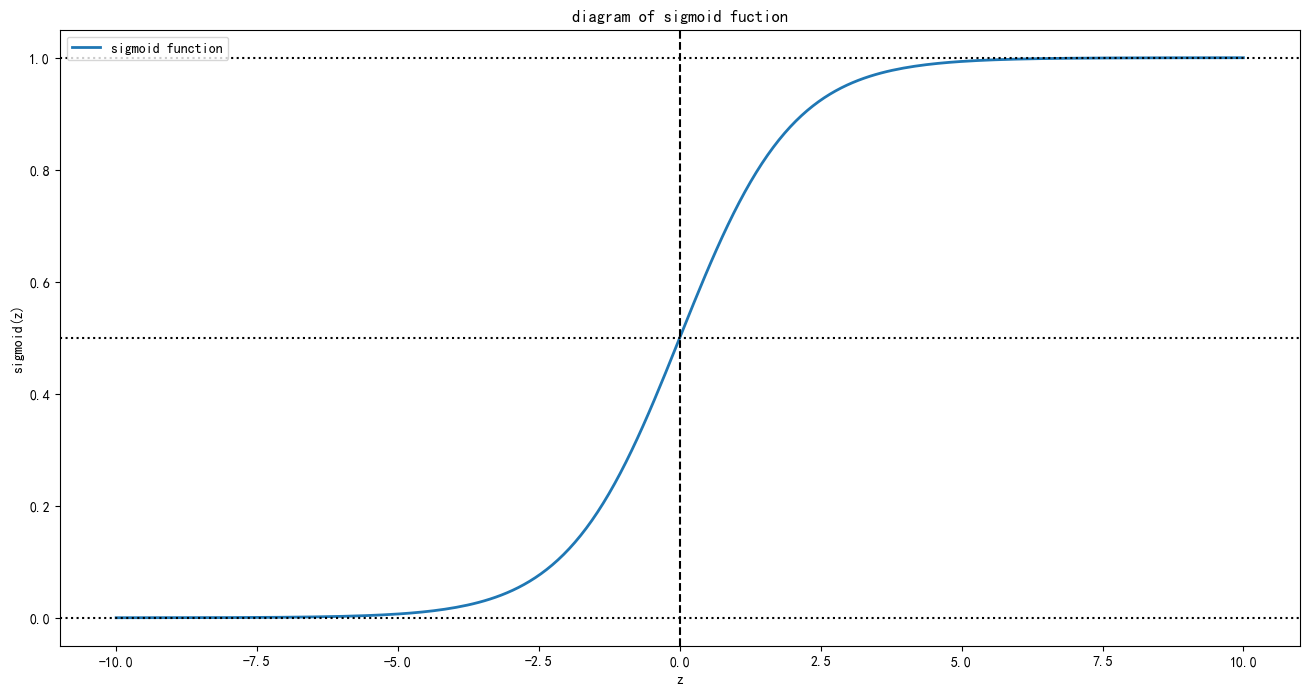

In [2]:
#todo:sigmoid
#todo:import specific dataset and package
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(16,8))
plt.rcParams['font.family']='SimHei'
plt.rcParams['axes.unicode_minus']=False #todo:set minus

#todo:sigmoid function
#todo:generating data
z=np.linspace(-10,10,200)
y=1/(1+np.exp(-z))
#todo: drawing the diagram
plt.plot(z,y,label='sigmoid function',linewidth=2)
#todo: vertical line
plt.axvline(x=0,ls='--',c='black')
#todo: Horizontal line
plt.axhline(y=1,ls=':',c='black')
plt.axhline(y=0,ls=':',c='black')
plt.axhline(y=0.5,ls=':',c='black')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('diagram of sigmoid fuction')
plt.legend()
plt.show()

In [3]:
# Step 2: Probabilistic model of logistic regression

# Let x denote the input features and w denote the model parameters.
# The linear combination is defined as: z = w · x

# Logistic regression models the probability of class membership using the sigmoid function:

# P(y = 1 | x, w) = s(z)
# P(y = 0 | x, w) = 1 - s(z)

# These two probabilities sum to 1.

# A unified representation for both classes is:
# P(y | x, w) = s(z)^y * (1 - s(z))^(1 - y)

# This formulation ensures:
# If y = 1 → P(y|x,w) = s(z)
# If y = 0 → P(y|x,w) = 1 - s(z)

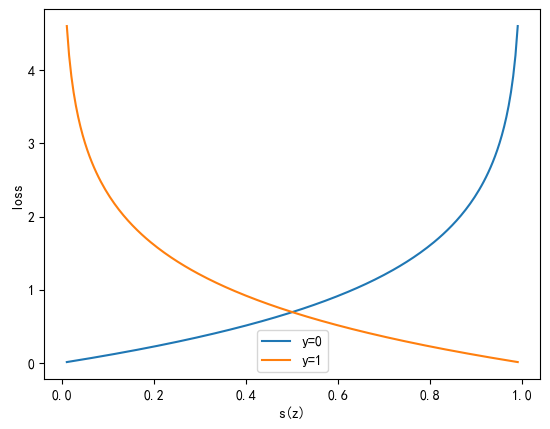

In [4]:
import matplotlib.pyplot as plt
s = np.linspace(0.01,0.99,200)
for y in [0,1]:
    loss = -(y*np.log(s)+(1-y)*np.log(1-s))
    plt.plot(s,loss,label=f"y={y}")
    plt.legend()
    plt.ylabel('loss')
    plt.xlabel('s(z)')

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore') # cmd of ignore warnings
iris = load_iris()
X,y=iris.data,iris.target
print(X)
print('after opreating: ')
X=X[y!=0,2:]
print(X)
y=y[y!=0]
y[y==1]=0
y[y==2]=1


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [6]:
#todo: divided training dataset and testing dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)
lg=LogisticRegression()
#todo: fitting
lg.fit(X_train,y_train)
#todo: forecasting
Y=lg.predict(X_test)
print(Y[:10])
print(lg.score(X_test,y_test))

[1 0 0 0 0 0 0 1 0 0]
0.9


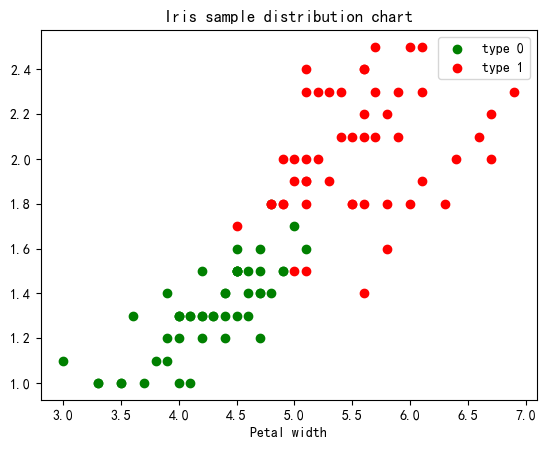

In [7]:
#visualization
import matplotlib.pyplot as plt
plt.rcParams['font.family']='SimHei'
c1=X[y==0]
c2=X[y==1]
plt.scatter(x=c1[:,0],y=c1[:,1],c='g',label='type 0')
plt.scatter(x=c2[:,0],y=c2[:,1],c='r',label='type 1')
# Extract the first feature (column 0) from c1 as the x-axis
# Extract the second feature (column 1) from c1 as the y-axis
plt.xlabel('Petal length')
plt.xlabel('Petal width')
plt.title('Iris sample distribution chart')
plt.legend()
plt.show()

In [8]:
#todo:calulate the Probability value
pro = lg.predict_proba(X_test)
print(pro)

[[0.45004392 0.54995608]
 [0.98464605 0.01535395]
 [0.73128894 0.26871106]
 [0.9157606  0.0842394 ]
 [0.80581498 0.19418502]
 [0.81975231 0.18024769]
 [0.58435701 0.41564299]
 [0.41295213 0.58704787]
 [0.80581498 0.19418502]
 [0.74890851 0.25109149]
 [0.30294788 0.69705212]
 [0.26033371 0.73966629]
 [0.49461735 0.50538265]
 [0.98634927 0.01365073]
 [0.74890851 0.25109149]
 [0.96075367 0.03924633]
 [0.96075367 0.03924633]
 [0.99442356 0.00557644]
 [0.17003017 0.82996983]
 [0.09066403 0.90933597]]


In [9]:
#todo:decision boundary
from matplotlib.colors import ListedColormap
def plot_decision_boundary(model,X,y):
    color=['r','g','b'] #todo: set color
    marker=['o','v','x'] #todo: set shape of data point
    class_label=np.unique(y)
    cmap=ListedColormap(color[:len(class_label)])
    x1_min,x2_min=np.min(X,axis=0)
    x1_max,x2_max=np.max(X,axis=0)
    x1=np.arange(x1_min-1,x1_max+1,0.02)
    x2=np.arange(x2_min-1,x2_max+1,0.02)
    X1,X2=np.meshgrid(x1,x2)
    Z=model.predict(np.array([X1.ravel(),X2.ravel()]).T).reshape(X1.shape)
    plt.contourf(X1,X2,Z,cmap=cmap,alpha=0.5)
    for i,class_ in enumerate(class_label):
        plt.scatter(x=X[y==class_,0],y=X[y==class_,1],c=cmap.colors[i],label=class_,marker=marker[i])
    plt.legend()

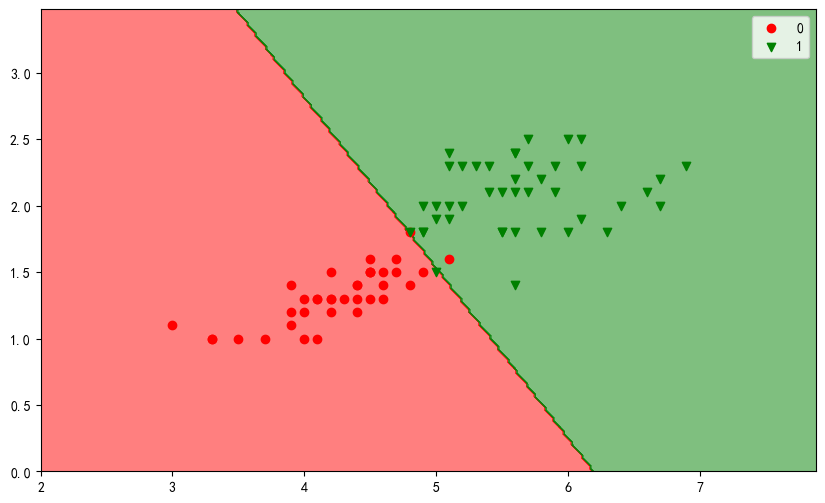

In [10]:
#todo: use function
plt.figure(figsize=(10,6))
plot_decision_boundary(lg,X_train,y_train)
plt.show()

[0 2 4]
[1 4 7]
********************
[0 2 4]
********************
[[1 1 1]
 [4 4 4]
 [7 7 7]]


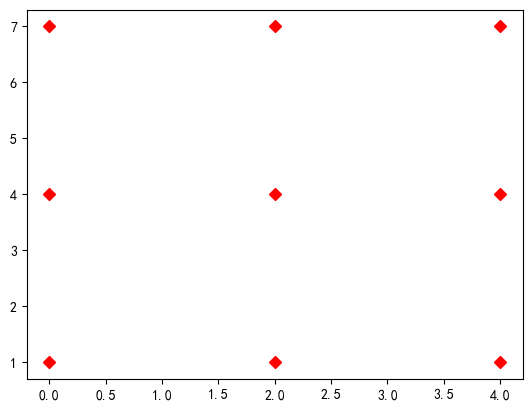

In [14]:
#todo: Cartesian product
x=np.arange(0,5,2)
y=np.arange(1,10,3)
print(x)
print(y)
print('*'*20)
X,Y=np.meshgrid(x,y)
print(x)
print('*'*20)
print(Y)
plt.plot(X,Y,color='red',marker='D',ls='')